# **Bài thực hành 4. Xem xét các thuộc tính lịch sử tài chính**

## **4.1. Bài tập 1: Xem xét thuộc tính trạng thái thanh toán**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/credit_card_clean_3.csv")

In [ ]:
print("Kích thước bộ dữ liệu:", df.shape)
print("Thông tin bộ dữ liệu: ")
df.info()

Kích thước bộ dữ liệu: (26664, 30)
Thông tin bộ dữ liệu: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26664 entries, 0 to 26663
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          26664 non-null  object
 1   LIMIT_BAL                   26664 non-null  int64 
 2   SEX                         26664 non-null  int64 
 3   EDUCATION                   26664 non-null  int64 
 4   MARRIAGE                    26664 non-null  int64 
 5   AGE                         26664 non-null  int64 
 6   PAY_1                       26664 non-null  int64 
 7   PAY_2                       26664 non-null  int64 
 8   PAY_3                       26664 non-null  int64 
 9   PAY_4                       26664 non-null  int64 
 10  PAY_5                       26664 non-null  int64 
 11  PAY_6                       26664 non-null  int64 
 12  BILL_AMT1                   26664 non-null  

In [ ]:
print("5 dòng đầu tiên của dữ liệu: ")
df.head(5)

5 dòng đầu tiên của dữ liệu: 


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,EDUCATION_CAT,graduate school,high school,others,university
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,1,university,False,False,False,True
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,1000,1000,0,2000,1,university,False,False,False,True
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,1000,1000,1000,5000,0,university,False,False,False,True
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,1200,1100,1069,1000,0,university,False,False,False,True
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,10000,9000,689,679,0,university,False,False,False,True


In [ ]:
pay_feats = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
display(df[pay_feats].describe())

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,-0.293579
std,1.126769,1.198640,1.199165,1.167897,1.131735,1.150229
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [ ]:
pay_feats = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
display(df[pay_feats].describe())

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,-0.293579
std,1.126769,1.198640,1.199165,1.167897,1.131735,1.150229
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [ ]:
print("Thống kê giá trị PAY_1:")
print(df['PAY_1'].value_counts().sort_index())

Thống kê giá trị PAY_1:
PAY_1
-2     2476
-1     5047
 0    13087
 1     3261
 2     2378
 3      292
 4       63
 5       23
 6       11
 7        9
 8       17
Name: count, dtype: int64


Các mốc bin: [-2.5 -1.5 -0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5]


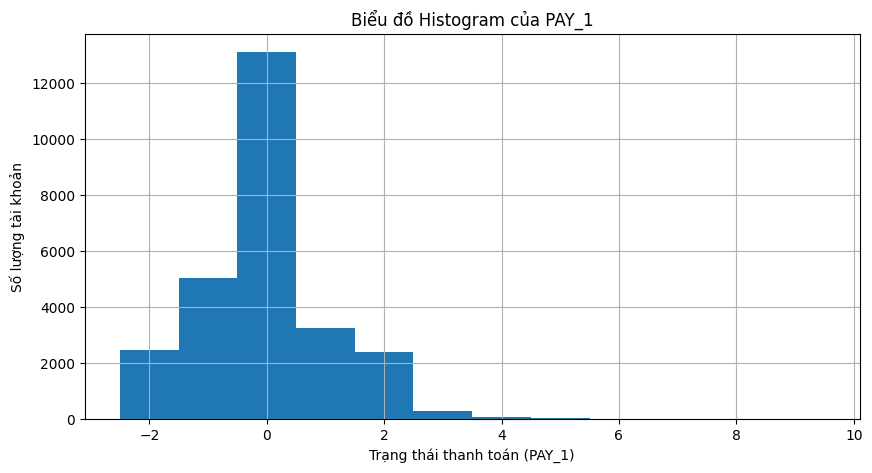

In [ ]:
pay_1_bins = np.array(range(-2, 11)) - 0.5
print(f"Các mốc bin: {pay_1_bins}")

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
df['PAY_1'].hist(bins=pay_1_bins)
plt.xlabel('Trạng thái thanh toán (PAY_1)')
plt.ylabel('Số lượng tài khoản')
plt.title('Biểu đồ Histogram của PAY_1')
plt.show()

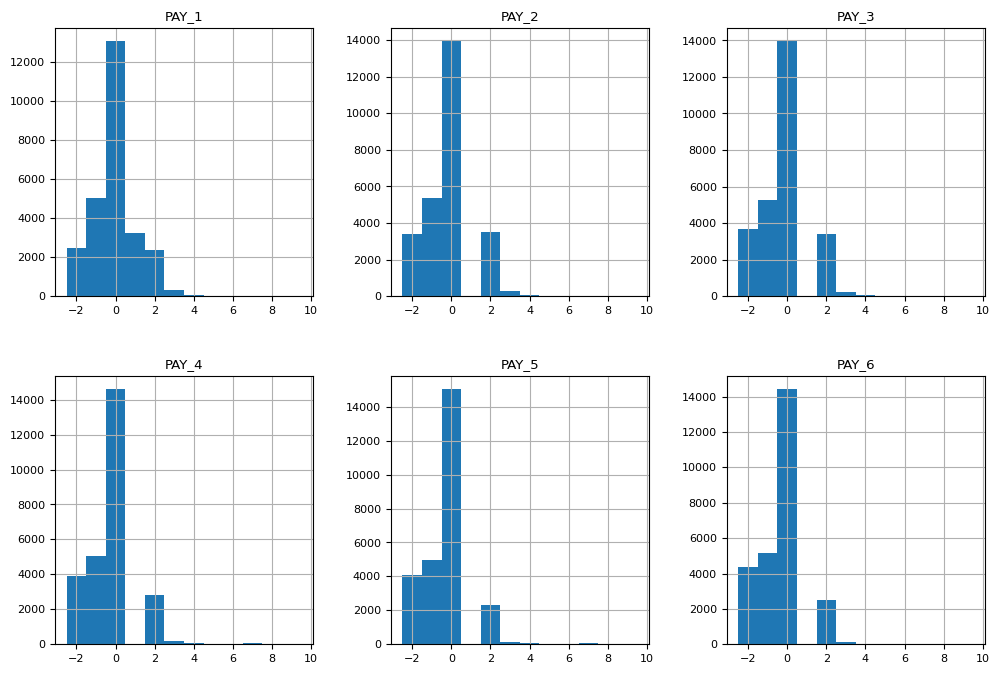

Kiểm tra logic giữa PAY_2 và PAY_3 khi PAY_2 = 2:


,PAY_2,PAY_3
0,2,-1
1,2,0
13,2,2
15,2,0
47,2,2
50,2,0
57,2,2
61,2,2
82,2,0
83,2,2


In [ ]:
mpl.rcParams['font.size'] = 8
df[pay_feats].hist(bins=pay_1_bins, layout=(2,3), figsize=(12, 8))
plt.show()

print("Kiểm tra logic giữa PAY_2 và PAY_3 khi PAY_2 = 2:")
display(df.loc[df['PAY_2']==2, ['PAY_2', 'PAY_3']].head(15))

Vấn đề phát hiện: Dữ liệu vi phạm logic trình tự thời gian.

Giải thích: Theo quy tắc nợ tín dụng, nếu tháng này khách hàng nợ 2 tháng `PAY_2` = 2, thì tháng trước đó họ phải nợ 1 tháng `PAY_3` = 1.

Thực tế: Dữ liệu cho thấy khi `PAY_2` = 2 thì `PAY_3` cũng bằng 2. Điều này là vô lý vì số tháng nợ không thể giữ nguyên khi nhìn ngược về quá khứ mà không có sự thay đổi trình tự `2 -> 1 -> 0`.

Hệ quả: Các cột lịch sử thanh toán `PAY_2` đến `PAY_6` có thể đã bị sao chép giá trị từ tháng gần nhất hoặc được ghi nhận không chính xác theo thời gian thực.

## **4.2. Bài tập 2: Xem xét các thuộc tính còn lại (Số tiền sao kê và Số tiền trả)**

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,51405.730723,49300.001500,47026.340047,43338.894539,40338.136701,38889.872337
std,73633.687106,70934.549534,68705.359524,64275.250740,60705.944083,59432.541657
min,-165580.000000,-69777.000000,-157264.000000,-170000.000000,-81334.000000,-339603.000000
25%,3580.000000,2999.750000,2627.250000,2341.750000,1745.000000,1256.000000
50%,22361.000000,21150.000000,20079.500000,19037.000000,18066.000000,17005.000000
75%,67649.750000,64395.500000,60360.000000,54727.500000,50290.500000,49253.750000
max,746814.000000,671563.000000,855086.000000,706864.000000,823540.000000,699944.000000


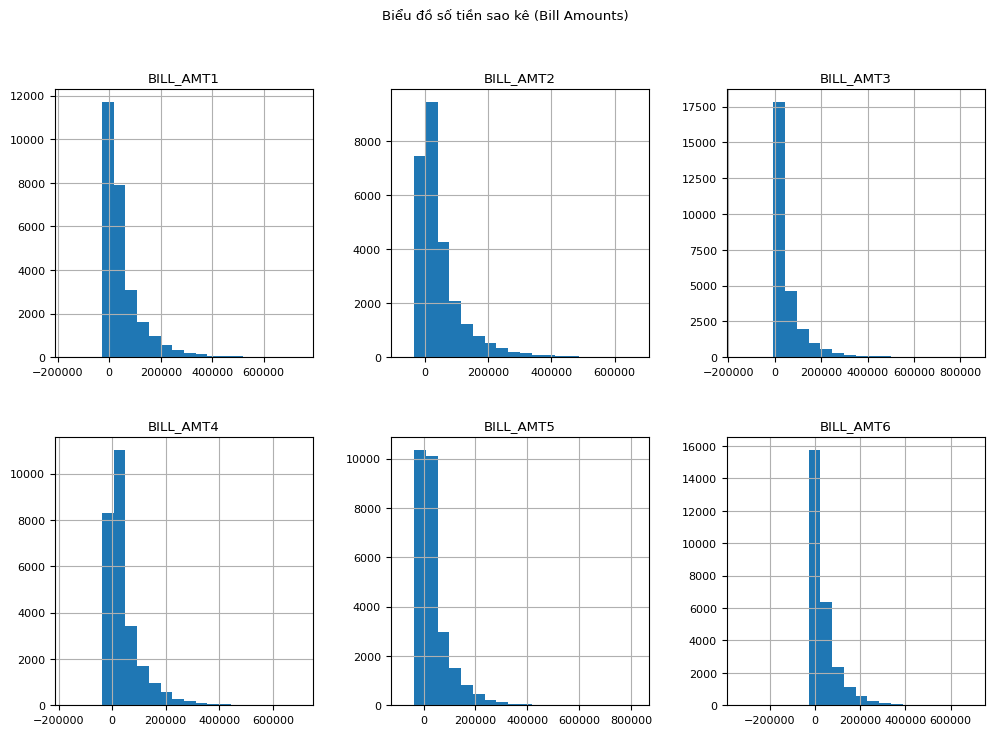

In [ ]:
bill_amt_feats = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Thống kê tổng quát
display(df[bill_amt_feats].describe())

# Trực quan hóa
df[bill_amt_feats].hist(bins=20, layout=(2, 3), figsize=(12, 8))
plt.suptitle('Biểu đồ số tiền sao kê (Bill Amounts)')
plt.show()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,26664.000000,2.666400e+04,26664.000000,26664.000000,26664.000000,26664.000000
mean,5704.085771,5.881110e+03,5259.514964,4887.048717,4843.729973,5257.843047
std,16699.398632,2.121431e+04,17265.439561,15956.349371,15311.721795,17635.468185
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1000.000000,8.020000e+02,390.000000,294.750000,242.750000,111.000000
50%,2114.500000,2.007000e+03,1822.000000,1500.000000,1500.000000,1500.000000
75%,5027.000000,5.000000e+03,4556.250000,4050.500000,4082.750000,4015.000000
max,873552.000000,1.227082e+06,889043.000000,621000.000000,426529.000000,528666.000000


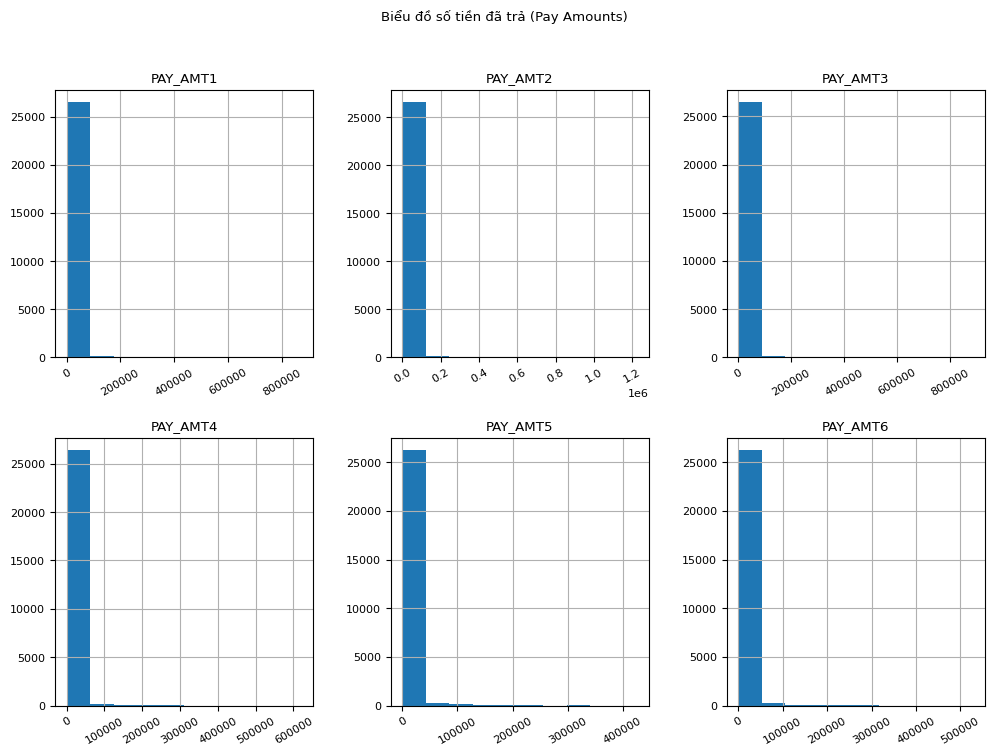

In [ ]:
pay_amt_feats = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Thống kê tổng quát
display(df[pay_amt_feats].describe())

# Trực quan hóa (xoay nhãn x 30 độ để tránh chồng lấp)
df[pay_amt_feats].hist(layout=(2, 3), xrot=30, figsize=(12, 8))
plt.suptitle('Biểu đồ số tiền đã trả (Pay Amounts)')
plt.show()

Số lượng giao dịch bằng 0 ở mỗi tháng:
PAY_AMT1    4656
PAY_AMT2    4833
PAY_AMT3    5293
PAY_AMT4    5697
PAY_AMT5    5981
PAY_AMT6    6373
dtype: int64


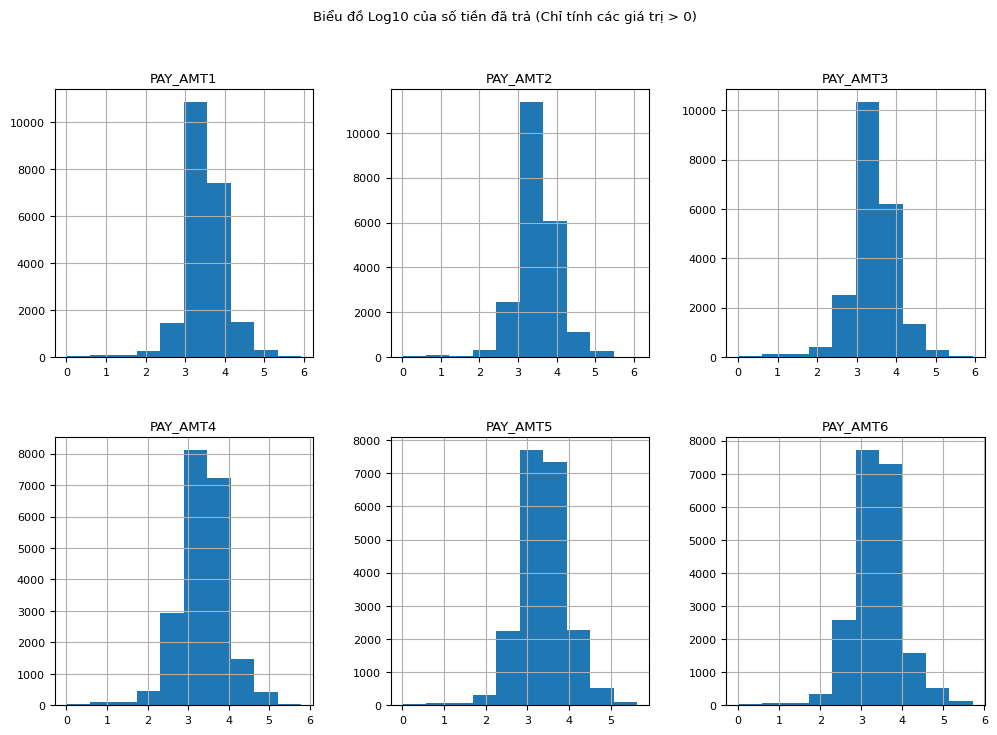

In [ ]:
pay_zero_mask = df[pay_amt_feats] == 0
print(f"Số lượng giao dịch bằng 0 ở mỗi tháng:\n{pay_zero_mask.sum()}")

df[pay_amt_feats][~pay_zero_mask].apply(np.log10).hist(layout=(2,3), figsize=(12, 8))
plt.suptitle('Biểu đồ Log10 của số tiền đã trả (Chỉ tính các giá trị > 0)')
plt.show()